In [60]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look cleaner
sns.set()

In [77]:
# Load Dataset

df = pd.read_csv("C:/Users/Penguin/Desktop/Global_Cybersecurity_Threats_2015-2024.csv")

# Display first 7 rows
df.head(7)

,Country,Year,Attack Type,Target Industry,Financial Loss (in Million $),Number of Affected Users,Attack Source,Security Vulnerability Type,Defense Mechanism Used,Incident Resolution Time (in Hours)
0,China,2019,Phishing,Education,80.53,773169,Hacker Group,Unpatched Software,VPN,63
1,China,2019,Ransomware,Retail,62.19,295961,Hacker Group,Unpatched Software,Firewall,71
2,India,2017,Man-in-the-Middle,IT,38.65,605895,Hacker Group,Weak Passwords,VPN,20
3,UK,2024,Ransomware,Telecommunications,41.44,659320,Nation-state,Social Engineering,AI-based Detection,7
4,Germany,2018,Man-in-the-Middle,IT,74.41,810682,Insider,Social Engineering,VPN,68
5,Germany,2017,Man-in-the-Middle,Retail,98.24,285201,Unknown,Social Engineering,Antivirus,25
6,Germany,2016,DDoS,Telecommunications,33.26,431262,Insider,Unpatched Software,VPN,34


In [78]:
# viewing the data types of columns
df.dtypes

Country                                 object
Year                                     int64
Attack Type                             object
Target Industry                         object
Financial Loss (in Million $)          float64
Number of Affected Users                 int64
Attack Source                           object
Security Vulnerability Type             object
Defense Mechanism Used                  object
Incident Resolution Time (in Hours)      int64
dtype: object

In [79]:
# Label Encoding for Country
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Country_Encoded'] = le.fit_transform(df['Country'])
df.dtypes

Country                                 object
Year                                     int64
Attack Type                             object
Target Industry                         object
Financial Loss (in Million $)          float64
Number of Affected Users                 int64
Attack Source                           object
Security Vulnerability Type             object
Defense Mechanism Used                  object
Incident Resolution Time (in Hours)      int64
Country_Encoded                          int64
dtype: object

In [80]:
# Date coversion
df['Year'] = pd.to_datetime(df['Year'], format='%Y')
df.dtypes

Country                                        object
Year                                   datetime64[ns]
Attack Type                                    object
Target Industry                                object
Financial Loss (in Million $)                 float64
Number of Affected Users                        int64
Attack Source                                  object
Security Vulnerability Type                    object
Defense Mechanism Used                         object
Incident Resolution Time (in Hours)             int64
Country_Encoded                                 int64
dtype: object

In [81]:
#Check Missing Values
print(df.isna().sum())

Country                                0
Year                                   0
Attack Type                            0
Target Industry                        0
Financial Loss (in Million $)          0
Number of Affected Users               0
Attack Source                          0
Security Vulnerability Type            0
Defense Mechanism Used                 0
Incident Resolution Time (in Hours)    0
Country_Encoded                        0
dtype: int64


In [82]:
# checking duplicate rows
df.duplicated()[df.duplicated()==True]

Series([], dtype: bool)

In [83]:
# finding number of rows and columns

print("Shape (rows, columns): ", df.shape,"\n")

print("number of rows: ", df.shape[0])
print("number of columns: ", df.shape[1])

Shape (rows, columns):  (3000, 11) 

number of rows:  3000
number of columns:  11


In [84]:
# Statistical summary
df.describe(include='all')

,Country,Year,Attack Type,Target Industry,Financial Loss (in Million $),Number of Affected Users,Attack Source,Security Vulnerability Type,Defense Mechanism Used,Incident Resolution Time (in Hours),Country_Encoded
count,3000,3000,3000,3000,3000.000000,3000.000000,3000,3000,3000,3000.000000,3000.000000
unique,10,NaN,6,7,NaN,NaN,4,4,5,NaN,NaN
top,UK,NaN,DDoS,IT,NaN,NaN,Nation-state,Zero-day,Antivirus,NaN,NaN
freq,321,NaN,531,478,NaN,NaN,794,785,628,NaN,NaN
mean,NaN,2019-07-28 09:28:19.200000,NaN,NaN,50.492970,504684.136333,NaN,NaN,NaN,36.476000,4.512333
min,NaN,2015-01-01 00:00:00,NaN,NaN,0.500000,424.000000,NaN,NaN,NaN,1.000000,0.000000
25%,NaN,2017-01-01 00:00:00,NaN,NaN,25.757500,255805.250000,NaN,NaN,NaN,19.000000,2.000000
50%,NaN,2020-01-01 00:00:00,NaN,NaN,50.795000,504513.000000,NaN,NaN,NaN,37.000000,5.000000
75%,NaN,2022-01-01 00:00:00,NaN,NaN,75.630000,758088.500000,NaN,NaN,NaN,55.000000,7.000000
max,NaN,2024-01-01 00:00:00,NaN,NaN,99.990000,999635.000000,NaN,NaN,NaN,72.000000,9.000000


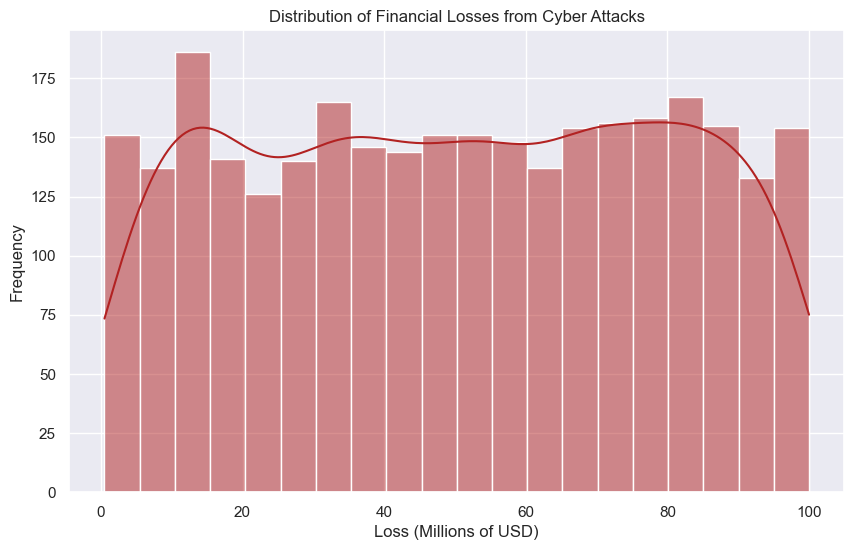

In [85]:
# Univariate Analysis
plt.figure(figsize=(10, 6))
sns.histplot(df['Financial Loss (in Million $)'], bins=20, kde=True, color='firebrick')
plt.title('Distribution of Financial Losses from Cyber Attacks')
plt.xlabel('Loss (Millions of USD)')
plt.ylabel('Frequency')
plt.show()

C:\Users\Penguin\AppData\Local\Temp\ipykernel_14444\1797591448.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Attack Type', palette='viridis',


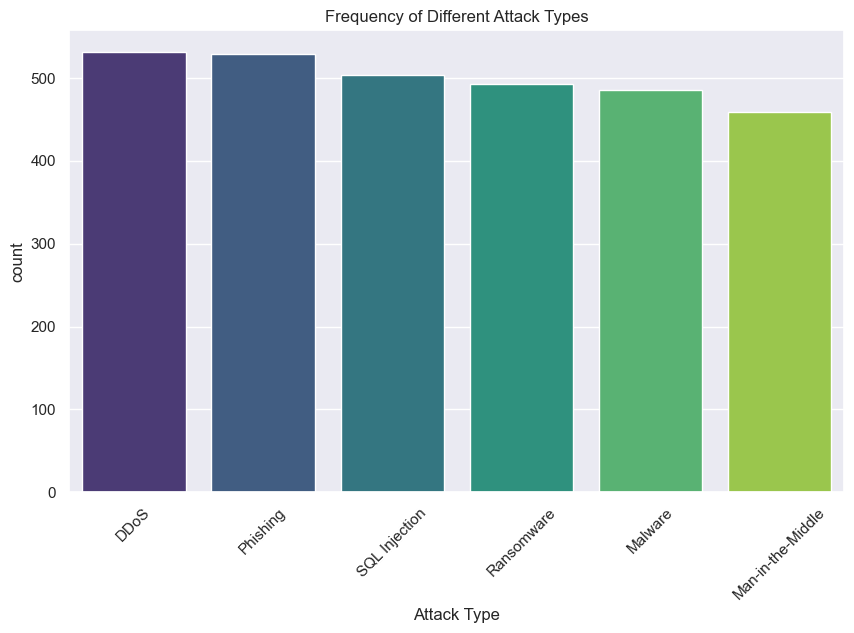

In [86]:
# Univariate Analysis
plt.figure(figsize=(10, 6))
# Using order to show them from most frequent to least
sns.countplot(data=df, x='Attack Type', palette='viridis', 
              order=df['Attack Type'].value_counts().index)

plt.title('Frequency of Different Attack Types')
plt.xticks(rotation=45) # Tilts the names so they don't overlap
plt.show()

C:\Users\Penguin\AppData\Local\Temp\ipykernel_14444\2347143756.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Attack Type', y='Financial Loss (in Million $)', palette='Set2')


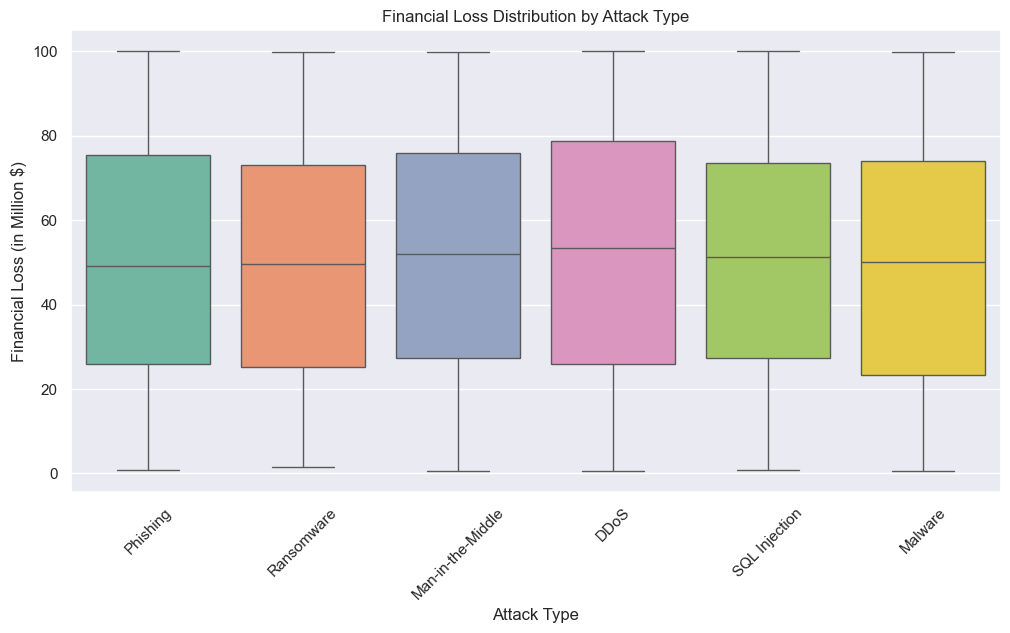

In [87]:
# Bivariate Analysis
# Attack Type vs. Financial Loss (in Million $)
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Attack Type', y='Financial Loss (in Million $)', palette='Set2')
plt.title('Financial Loss Distribution by Attack Type')
plt.xticks(rotation=45)
plt.show()

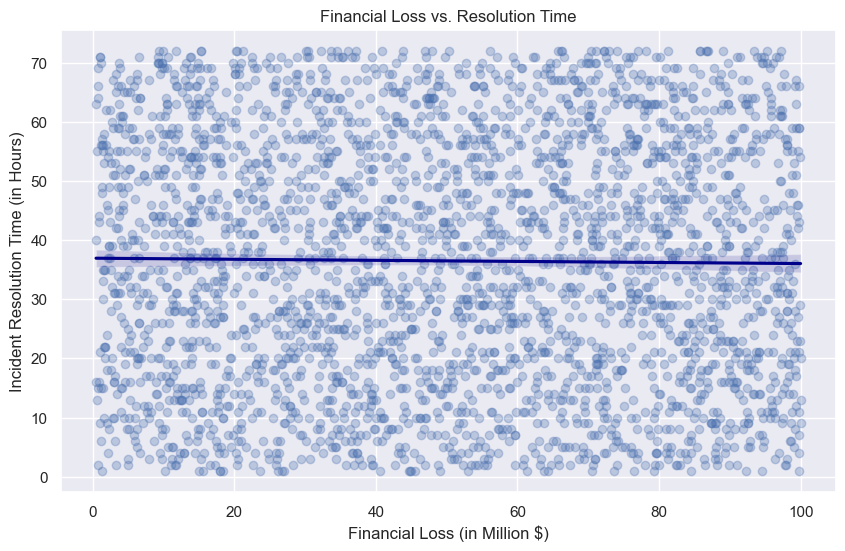

In [88]:
# Financial Loss (in Million $) vs. Incident Resolution Time (in Hours).
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='Financial Loss (in Million $)', y='Incident Resolution Time (in Hours)', 
            scatter_kws={'alpha':0.3}, line_kws={'color':'darkblue'})
plt.title('Financial Loss vs. Resolution Time')
plt.show()

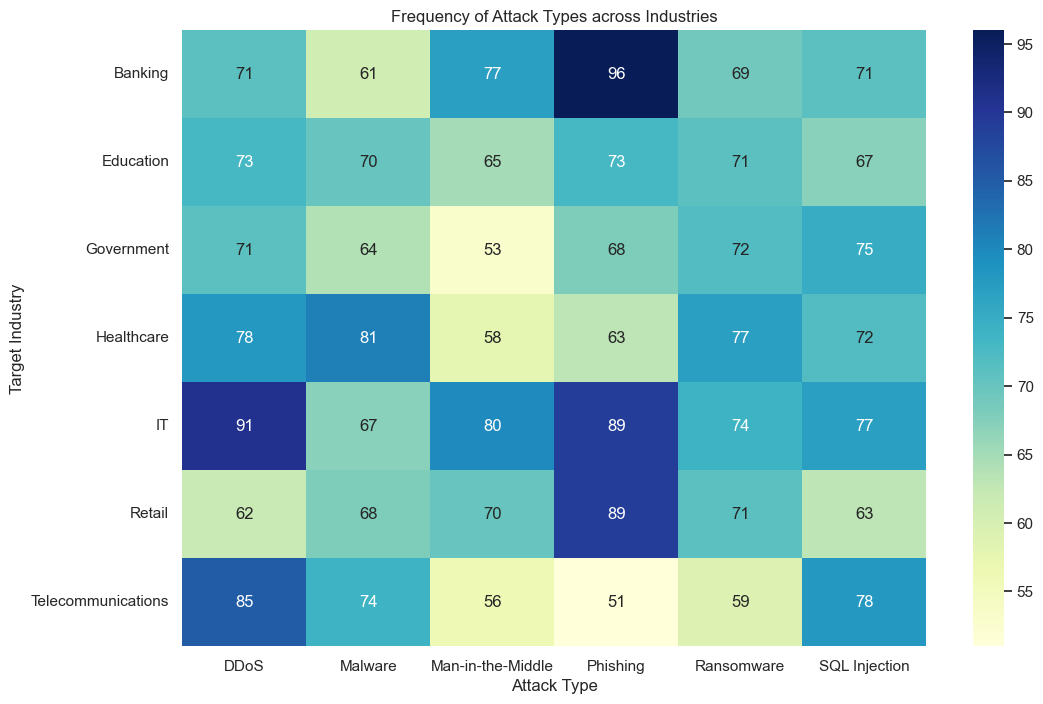

In [89]:
# Target Industry vs. Attack Type
pivot_table = pd.crosstab(df['Target Industry'], df['Attack Type'])

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_table, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Frequency of Attack Types across Industries')
plt.show()

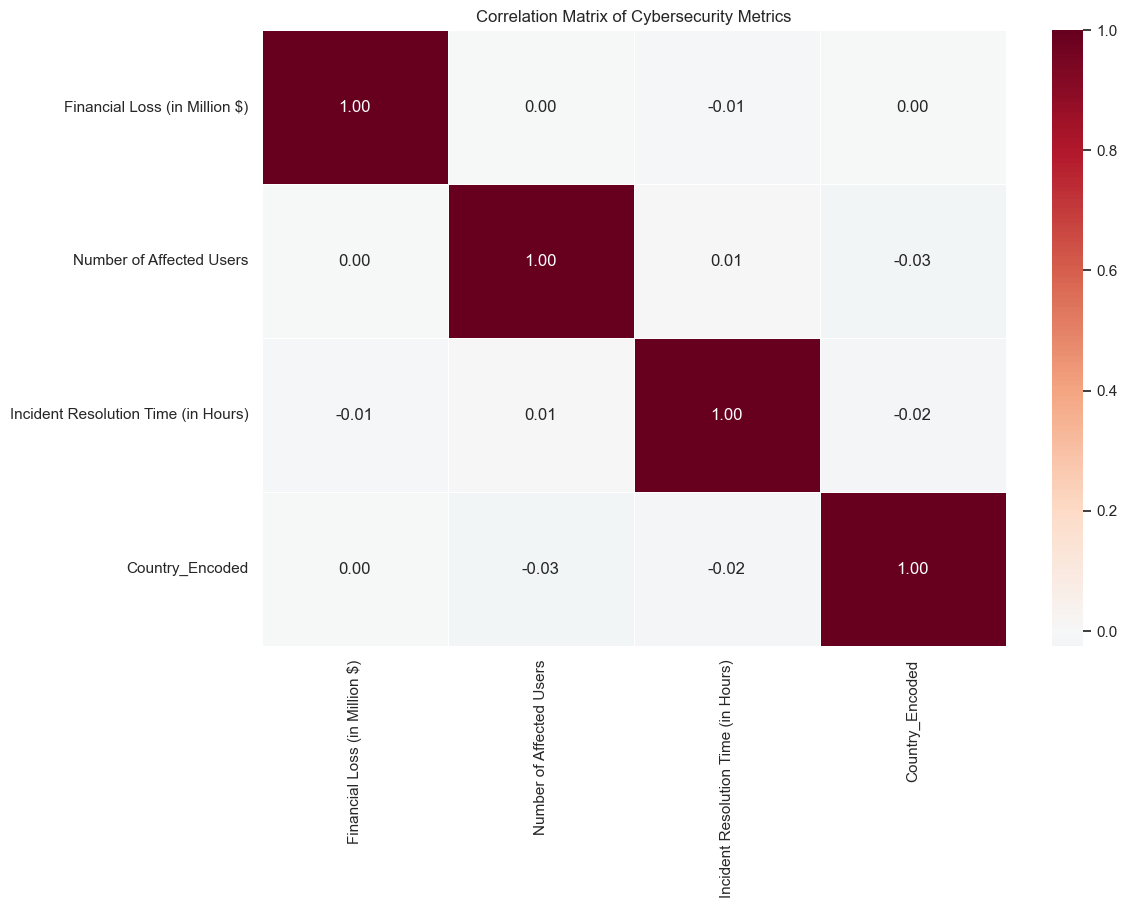

In [90]:
# Correlation Matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Select only the numerical columns for correlation
numeric_df = df.select_dtypes(include=['number'])

# Calculate the correlation matrix
corr_matrix = numeric_df.corr()

# Create the Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt=".2f", linewidths=0.5)

plt.title('Correlation Matrix of Cybersecurity Metrics')
plt.show()

In [91]:
# Time-Based Analysis
# Grouping data to see the average financial loss and total attacks per year
yearly_stats = df.groupby('Year').agg({
    'Financial Loss (in Million $)': 'mean',
    'Attack Type': 'count'
}).rename(columns={'Attack Type': 'Total Attacks'})

print(yearly_stats)

            Financial Loss (in Million $)  Total Attacks
Year                                                    
2015-01-01                      52.383430            277
2016-01-01                      48.937754            285
2017-01-01                      50.977053            319
2018-01-01                      47.485419            310
2019-01-01                      49.941787            263
2020-01-01                      50.056984            315
2021-01-01                      53.088328            299
2022-01-01                      49.908365            318
2023-01-01                      50.660571            315
2024-01-01                      51.619699            299


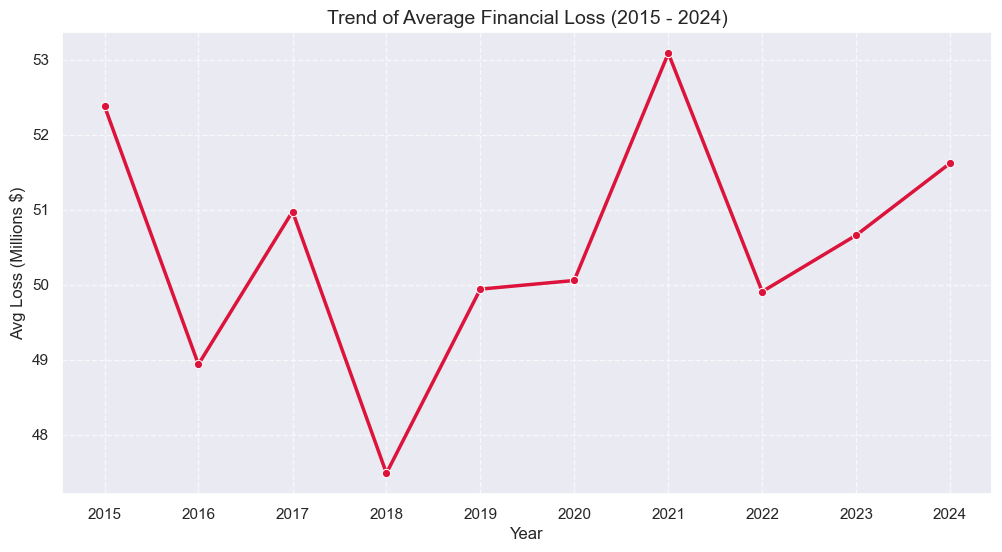

In [92]:
plt.figure(figsize=(12, 6))

# Plotting Average Financial Loss over time
sns.lineplot(data=yearly_stats, x=yearly_stats.index, y='Financial Loss (in Million $)', 
             marker='o', color='crimson', linewidth=2.5)

plt.title('Trend of Average Financial Loss (2015 - 2024)', fontsize=14)
plt.ylabel('Avg Loss (Millions $)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()